In [ ]:
import time
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from core.dgp import ARProcess, ARGARCHProcess, IIDProcess, NormalInnov, StudentTInnov
from core.synth import TrajectorySpec, SyntheticGenerator, summary
from core.models import IIDNormalModel, IIDStudentTModel, IIDNonNormalModel, REGISTRY
from core.coverage import run_pair

In [31]:
def plot_execution_times(df, hue_col):
    """
    Plots execution time bar charts from the benchmark DataFrame.
    
    Parameters:
    df (pd.DataFrame): The raw results DataFrame (must contain 'Length', 'n', 'Time (s)', and hue_col).
    hue_col (str): The column name to use for color grouping (e.g., 'DGP', 'Pair').
    """
    # Set a clean style for the plots
    sns.set_theme(style="whitegrid")

    # ---------------------------------------------------------
    # Plot 1: How time scales with LENGTH (for different 'n's)
    # ---------------------------------------------------------
    g1 = sns.catplot(
        data=df, 
        x="Length", 
        y="Time (s)", 
        hue=hue_col, 
        col="n", 
        kind="bar", 
        height=4, 
        aspect=1.2,
        sharey=False
    )
    g1.fig.suptitle(f"Execution Time vs. Trajectory Length (Faceted by n)", y=1.05)
    g1.set_axis_labels("Trajectory Length", "Time (seconds)")

    plt.show()

    # ---------------------------------------------------------
    # Plot 2: How time scales with 'n' (for different Lengths)
    # ---------------------------------------------------------
    g2 = sns.catplot(
        data=df, 
        x="n", 
        y="Time (s)", 
        hue=hue_col, 
        col="Length", 
        kind="bar", 
        height=4, 
        aspect=1.2,
        sharey=False
    )
    g2.fig.suptitle(f"Execution Time vs. Number of Trajectories (Faceted by Length)", y=1.05)
    g2.set_axis_labels("Number of Trajectories (n)", "Time (seconds)")

    plt.show()


In [ ]:


# Grid
lengths =  [50, 100, 500] 
ns = [10**e for e in [0, 3, 4]]

# List to hold the raw results
results = []

# 2. Loop over combinations of (length, n)
for length, n in itertools.product(lengths, ns):
    
    # Define the specs inside the loop to capture current 'length' and 'n'
    dgp_specs = {
        "iid_normal": TrajectorySpec(
            IIDProcess(NormalInnov()).calibrate_params(mu=1.5, sigma=1),     
            "iid_normal",  n=n, length=length
        ),
        "iid_student": TrajectorySpec(
            IIDProcess(StudentTInnov(df=5.5)).calibrate_params(mu=1.5, sigma=1),     
            "iid_student",  n=n, length=length
        ),
        "ar1_normal":TrajectorySpec(
            ARProcess(phi=[0.6], innov=NormalInnov()).calibrate_params(mu=1.5, sigma=1),     
            "ar1_normal",  n=n, length=length
        ),
    }
    
    for dgp_name, spec in dgp_specs.items():
        
        # Start high-precision timer
        start_time = time.perf_counter()
        
        # Generate the data
        data = SyntheticGenerator(seed=42).generate([spec])
        
        # Stop timer
        end_time = time.perf_counter()
        elapsed_time = end_time - start_time
        
        # Append the record
        results.append({
            "Length": length,
            "n": n,
            "DGP": dgp_name,
            "Time (s)": elapsed_time
        })

# 4. Convert to a DataFrame and format for presentation
df_raw_gen = pd.DataFrame(results)

# Pivot the table for a clean comparative view
# Rows = Length and n | Columns = DGPs | Values = Time taken
df_summary_gen = df_raw_gen.pivot(index=["Length", "n"], columns="DGP", values="Time (s)")

print("=== Execution Time Summary (Seconds) ===")
print(df_summary_gen)

=== Execution Time Summary (Seconds) ===
DGP           iid_normal  iid_student
Length n                             
50     1        0.016936     0.002512
       1000     0.212263     0.218436
       10000    2.534526     2.928676
100    1        0.004297     0.001896
       1000     0.237347     0.240441
       10000    2.720636     2.723514
500    1        0.002896     0.001621
       1000     0.316065     0.333486
       10000    3.722205     3.731246


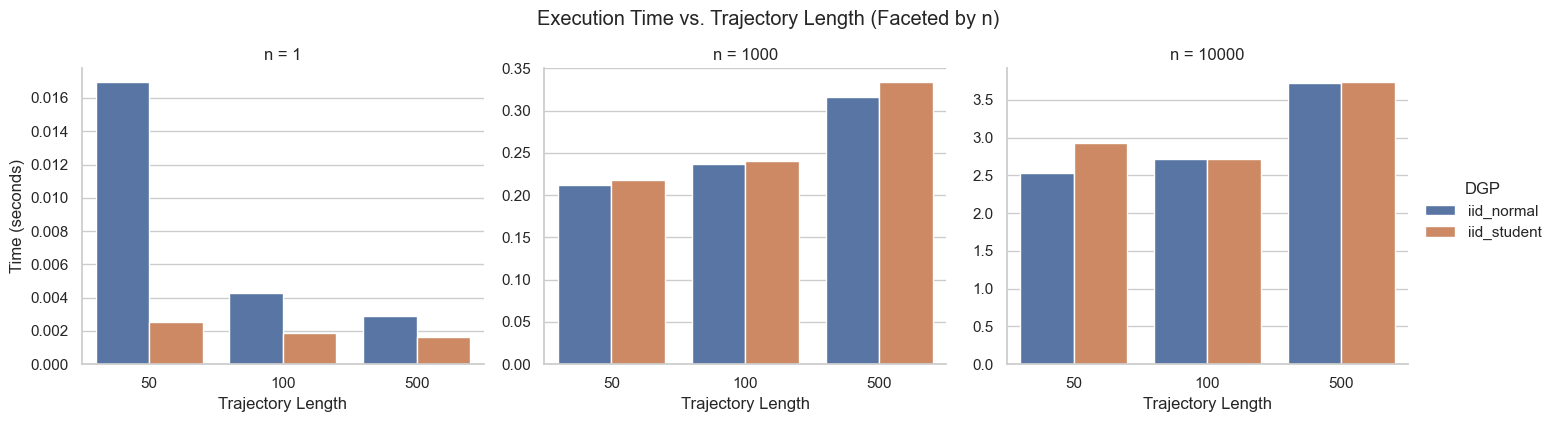

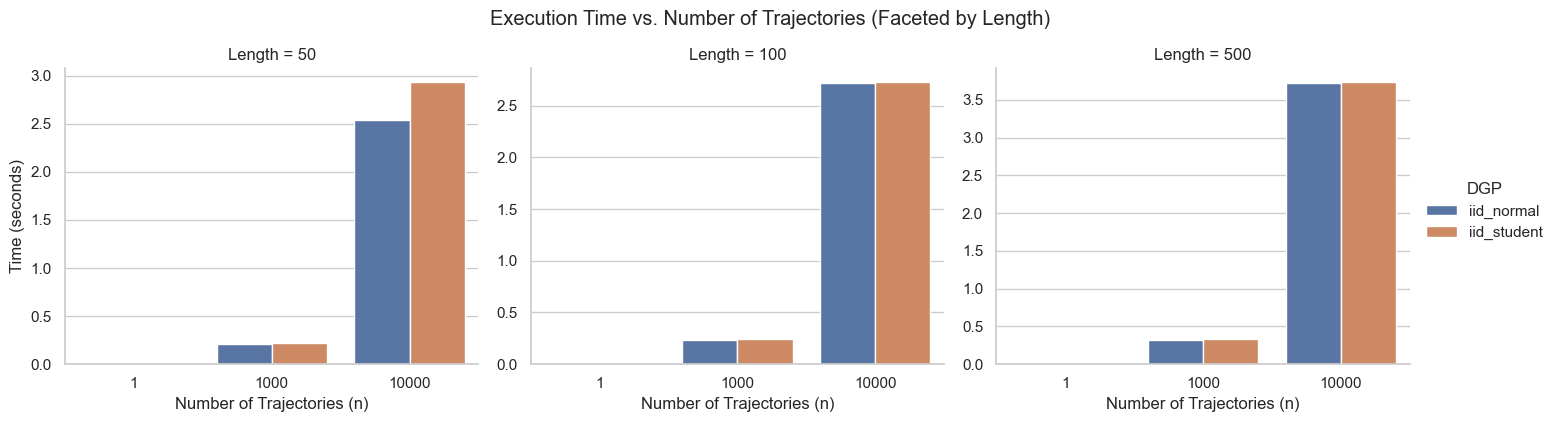

In [34]:
plot_execution_times(df_raw_gen, "DGP")

In [ ]:


lengths =  [50, 100, 500] 
ns = [10**e for e in [0, 3, 4]]

true_sr=0.5
alpha=0.05
th_moments=False

# FIX: Move model definitions outside the loop since they don't change with length/n
model_names = ["iid_normal", "iid_student_t", "iid_nonnormal", "ar1_normal"]
model_specs = {name: REGISTRY[name] for name in model_names if name in REGISTRY}

# List to hold the raw results
results = []

# 2. Loop over combinations of (length, n)
for length, n in itertools.product(lengths, ns):
    
    # Define the specs inside the loop to capture current 'length' and 'n'
    dgp_specs = {
        "iid_normal": TrajectorySpec(
            IIDProcess(NormalInnov()).calibrate_params(mu=0.5, sigma=1), # sr=0.5 
            "iid_normal",  n=n, length=length
        ),
        "iid_student": TrajectorySpec(
            IIDProcess(StudentTInnov(df=5.5)).calibrate_params(mu=0.5, sigma=1),     
            "iid_student",  n=n, length=length
        )
    }
    
    # FIX: Use .items() to get both the name (key) and the object (value)
    for (dgp_name, dgp_obj), (model_name, model_obj) in itertools.product(dgp_specs.items(), model_specs.items()):
        
        # Start high-precision timer
        start_time = time.perf_counter()
        
        # test run
        pair_rng = np.random.default_rng(42)
        # FIX: Pass the objects directly instead of using .value
        run_pair(dgp_obj.dgp, model_obj, true_sr, length, n, alpha, th_moments, pair_rng)
        
        # Stop timer
        elapsed_time = time.perf_counter() - start_time
        
        # Append the record
        results.append({
            "Length": length,
            "n": n,
            "Pair": f"DGP={dgp_name} Model={model_name}", # Clarified column name
            "Time (s)": elapsed_time
        })

# 4. Convert to a DataFrame and format for presentation
df_raw_coverage = pd.DataFrame(results)

# Pivot the table for a clean comparative view
# Rows = Length and n | Columns = Pairs | Values = Time taken
df_summary_coverage = df_raw_coverage.pivot(index=["Length", "n"], columns="Pair", values="Time (s)")

print("=== Execution Time Summary (Seconds) ===")
print(df_summary_coverage)

=== Execution Time Summary (Seconds) ===
Pair          DGP=iid_normal Model=iid_nonnormal  \
Length n                                           
50     1                                0.001114   
       1000                             0.804716   
       10000                            8.256006   
100    1                                0.000968   
       1000                             0.818278   
       10000                            8.301831   
500    1                                0.000995   
       1000                             0.976496   
       10000                            8.229594   

Pair          DGP=iid_normal Model=iid_normal  \
Length n                                        
50     1                             0.000365   
       1000                          0.034532   
       10000                         0.248907   
100    1                             0.000235   
       1000                          0.026582   
       10000                         0.2658

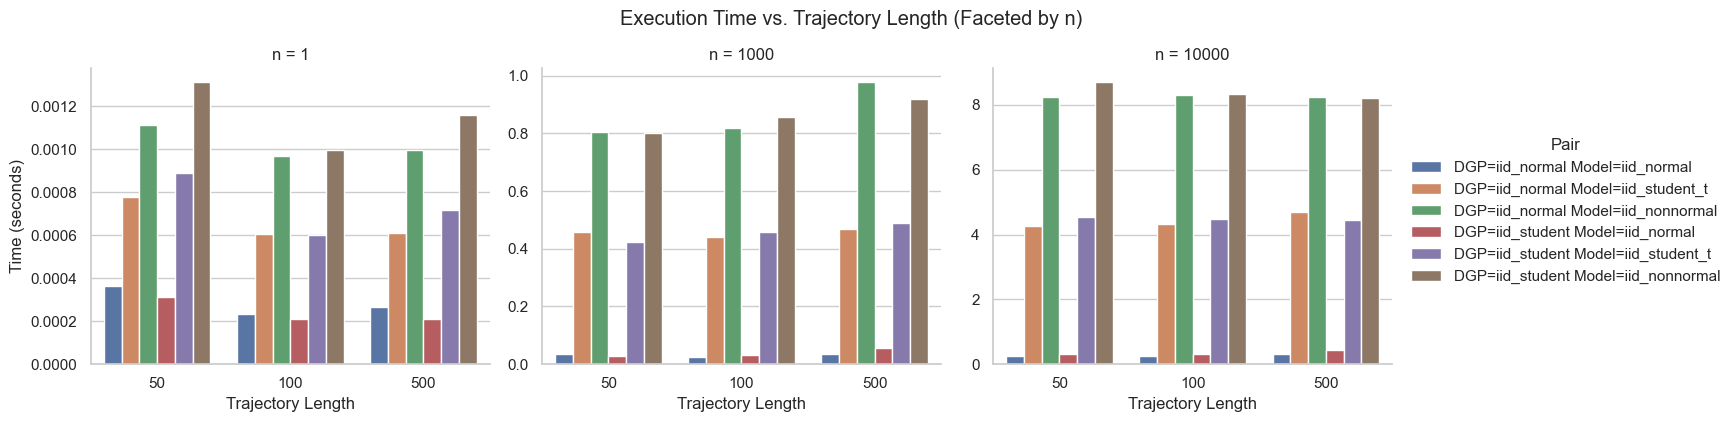

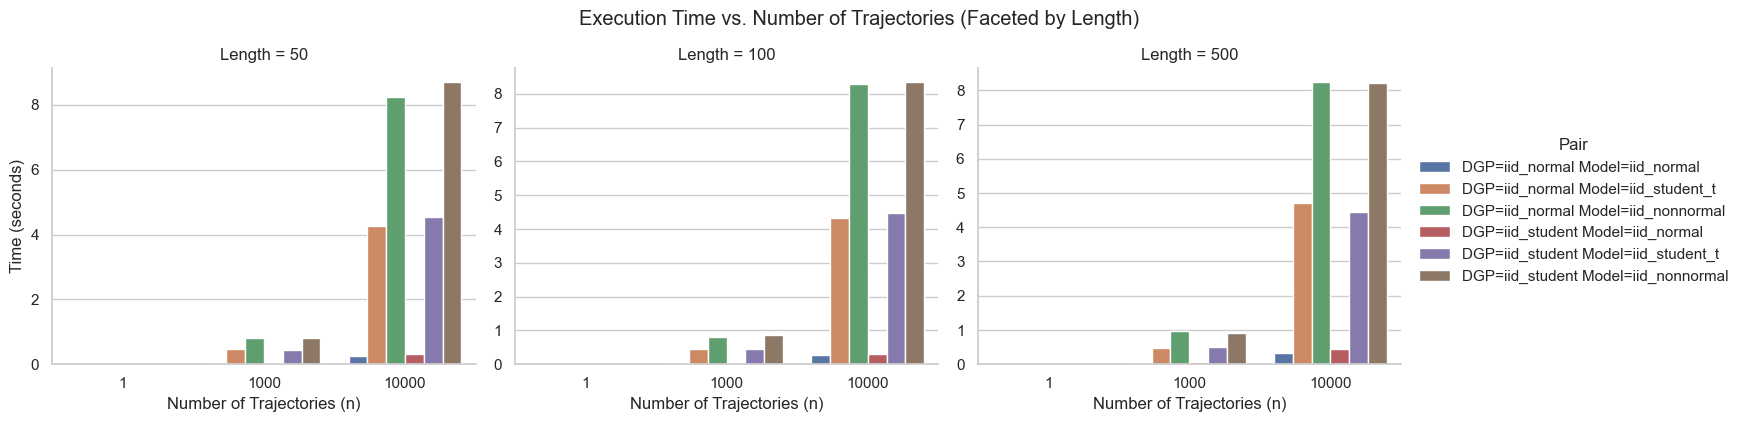

In [32]:
plot_execution_times(df_raw_coverage, "Pair")

seems like the fit method penalizes a lot (kurt and skew), nonnormal the worts because calculates both